In [1]:
from tg_analysis import *

In [2]:
mode = "constant_I" # "constant_I"

if mode == "constant_E":
    params_scan = {"E": 63.6, "I": "all"}
elif mode == "constant_I":
    params_scan = {"E": "all", "I": 2.0}
else:
    raise ValueError("Invalid mode")

model_idxs = 1#[3,3,3,2,2,2,2,2,2]


In [3]:
json_path_CoOx12 = "/Users/manuelfernandosanchezalarcon/Desktop/Trieste_Project/Transient_Grating/transient_grating_project/external_files/parameters_CoOx12.json"
analysis_CoOx12 = TGAnalysis(json_path_CoOx12)

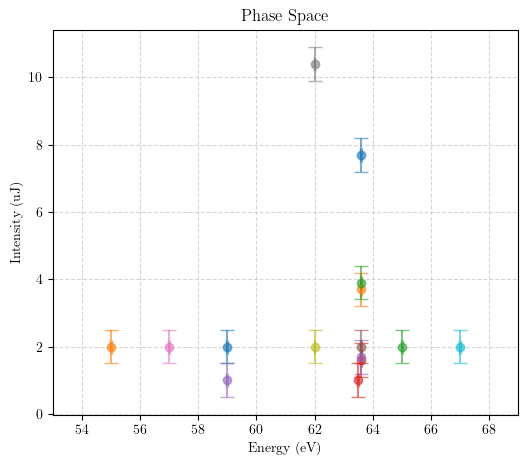

In [4]:
analysis_CoOx12.plot_phase_space(errors_bool=True, save_path="../report/figures/phase_space.png")

In [5]:
analysis_CoOx12.get_data_scan(params_scan)

In [6]:
analysis_CoOx12.get_fit_parameters(model_idxs=model_idxs, initial_guess_bool=True, bounds=True)

/Users/manuelfernandosanchezalarcon/Desktop/Trieste_Project/Transient_Grating/transient_grating_project/src/tg_analysis.py:438: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


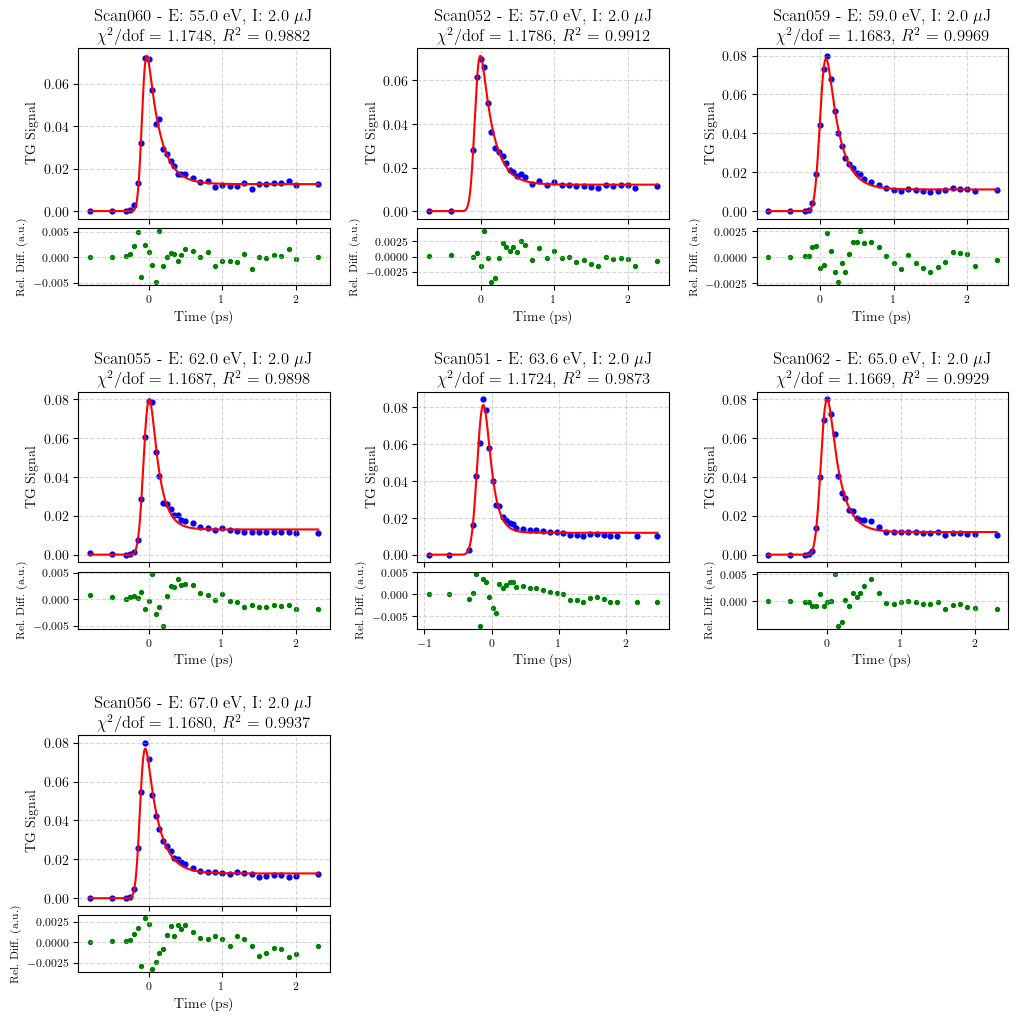

In [7]:
analysis_CoOx12.plot_fits(save_path=f"../report/figures/fits_{mode}_model{model_idxs}.png")

In [8]:
param_name = "tau"

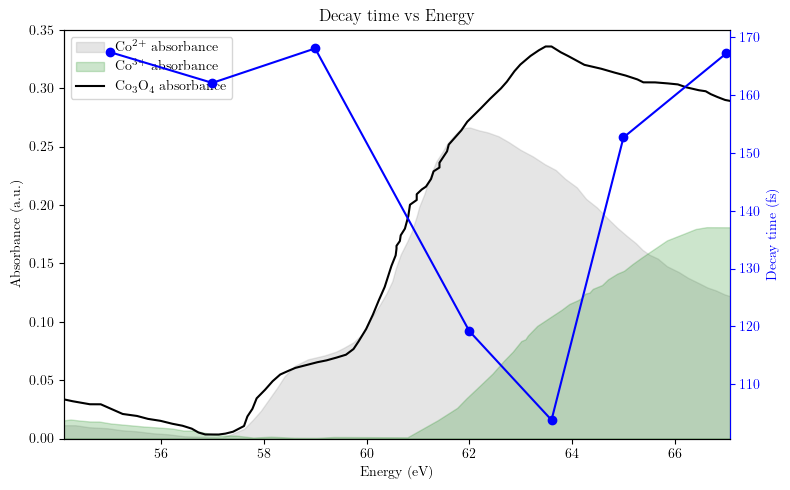

In [9]:
if mode == "constant_E":
    analysis_CoOx12.plot_params_vs_intensity(param_name=param_name, errors_bool=False, save_path=f"../report/figures/{param_name}_{mode}_model{model_idxs}.png")
elif mode == "constant_I":
    analysis_CoOx12.plot_params_vs_energy(param_name=param_name, errors_bool=False, save_path=f"../report/figures/{param_name}_{mode}_model{model_idxs}.png")
else:
    raise ValueError("Invalid mode")

/Users/manuelfernandosanchezalarcon/Desktop/Trieste_Project/Transient_Grating/transient_grating_project/Env_TG/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/manuelfernandosanchezalarcon/Desktop/Trieste_Project/Transient_Grating/transient_grating_project/Env_TG/lib/python3.14/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


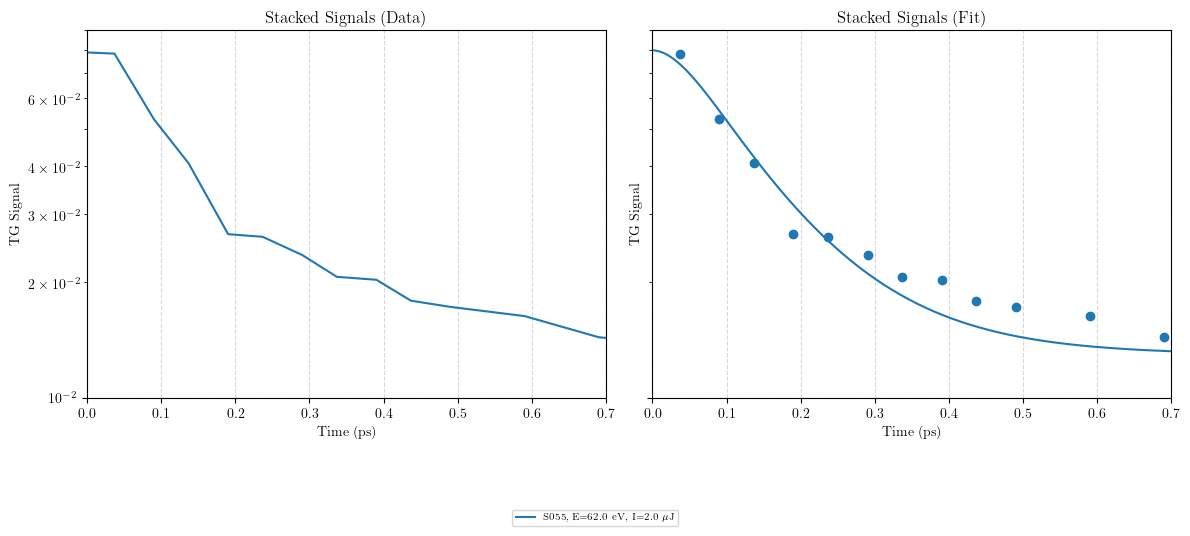

In [10]:
limits_time = (0.0, 0.7)#(-0.5,2.0)
limits_signal = (0.01, 0.09)#(-0.1,1.1)
ylog_scale = True #False
plot_ind = [3]#None

analysis_CoOx12.plot_stacked_signals(limits_time=limits_time, limits_signal=limits_signal, ylog_scale=ylog_scale, plot_ind=plot_ind, data_over_fit=True)

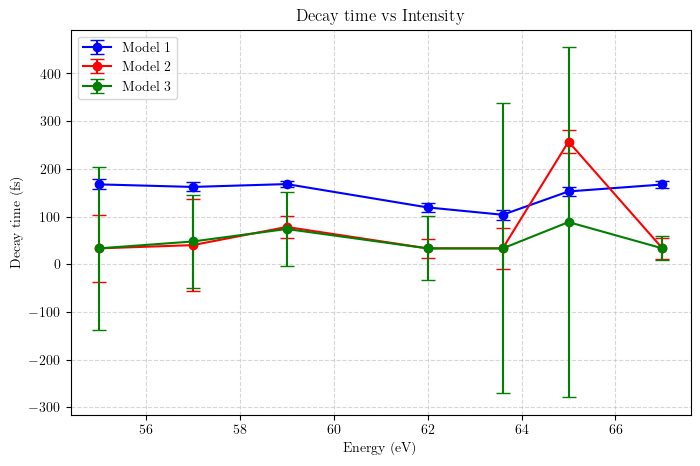

In [11]:
#models_config = [
#    {"model_idxs": 1, "initial_guess_bool": True, "bounds": True},
#    {"model_idxs": 2, "initial_guess_bool": False, "bounds": True},
#    {"model_idxs": 3, "initial_guess_bool": False, "bounds": True},
#    {"model_idxs": 4, "initial_guess_bool": True, "bounds": True},
#]

models_config = [
    {"model_idxs": 1, "initial_guess_bool": True, "bounds": True, "label_model": "Model 1", "color": "blue"},
    {"model_idxs": 2, "initial_guess_bool": True, "bounds": True, "label_model": "Model 2", "color": "red"},
    {"model_idxs": 3, "initial_guess_bool": True, "bounds": True, "label_model": "Model 3", "color": "green"}
]
analysis_CoOx12.plot_params_all_models(models_config, param_name=param_name, mode = mode, errors_bool=True, save_path=f"../report/figures/{param_name}_{mode}_all_models.png")